## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneGroupOut,
    cross_validate, cross_val_predict, cross_val_score,
)
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap

from sklearn.metrics import f1_score, roc_auc_score
import shap
shap.initjs()

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

In [2]:
BINARY_PFS = True
RNA_SEQ_ONLY = True

pfs_dir = "binary" if BINARY_PFS else "three-classes"
rna_suffix = "_rna" if RNA_SEQ_ONLY else ""

In [3]:
# Load gex_mat_corrected
gex_mat = pd.read_csv(f"../dataset/created/{pfs_dir}/gex_mat_corrected{rna_suffix}.csv").set_index('sample_id').T
gex_mat['sample_id'] = gex_mat.index

print(gex_mat.shape)
gex_mat.head()

(78, 23387)


sample_id,A1BG-AS1,A1CF,A2M-AS1,A2ML1,A3GALT2,A4GALT,A4GNT,AA06,AAAS,AACS,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,sample_id
03660555B,0.892848,-0.014449,2.669098,0.016093,-0.250163,2.143437,-0.206612,0.0,5.553840,3.031676,...,3.097789,0.556946,1.192834,2.773766,0.052665,2.079754,6.546661,2.954971,2.939248,03660555B
03660598B,1.250526,-0.021733,3.973917,0.282158,-0.119886,1.474063,-0.020543,0.0,5.496134,3.183949,...,3.505208,0.697100,1.042928,2.612191,-0.003464,2.432721,5.618133,2.969150,2.586618,03660598B
03660602B,1.337167,-0.014759,2.973871,0.194465,-0.122425,1.704613,0.318386,0.0,4.832991,2.218299,...,2.859687,0.707183,1.066919,2.500457,0.260227,2.217228,6.528220,3.161277,3.463558,03660602B
04240076F,0.696176,-0.019675,2.393908,0.602224,-0.202191,2.990010,0.042588,0.0,4.535571,2.436898,...,2.718169,0.797301,1.066046,2.408641,-0.027371,2.047882,6.690812,3.135011,2.232254,04240076F
04240106F,1.178242,-0.030725,2.639825,0.045172,0.665199,1.758596,-0.171676,0.0,5.661363,2.146097,...,1.821515,0.810193,1.336957,2.891467,-0.052370,2.847988,5.547082,3.319700,3.505455,04240106F


In [4]:
# Load clinical_gex
clinical_gex = pd.read_csv(f"../dataset/created/{pfs_dir}/clinical_gex{rna_suffix}.csv", low_memory=False)

print(clinical_gex.shape)
clinical_gex.head()

(78, 51483)


,patientID,sex,age,AJCC_stage,M_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,source,pfs_label,...,sept-05,sept-06,sept-07,sept-08,sept-09,sept-10,sept-11,sept-12,sept-14,sept-15
0,YR_3053,male,26,IV,M1B,elevated,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,YR_3708,female,58,IV,M1A,normal,no,no,Yan et al.,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,YR_3705,male,45,IV,M1A,normal,no,no,Yan et al.,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,YR_1106,male,48,IIIC,NaN,normal,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,YR_1110,male,33,IV,M1C,normal,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Clinical feature groups
clinical_ordinal_col    = ['M_stage']
clinical_categorical_cols = ['sex', 'AJCC_stage', 'LDH', 'immunotherapy_treatment', 'pre_MAPKi_treatment']
clinical_numeric_col    = ['age']
clinical_drug_braf_cols = ['cobimetinib', 'trametinib', 'dabrafenib', 'vemurafenib',
                           'C195W', 'K601I', 'MND', 'V600E', 'V600K', 'V600R'] 
clinical_remaining_cols = ['patientID', 'sample_id', 'pfs_label', 'source']

In [6]:
# sometime certain drugs or gene are missing in the dataset
clinical_drug_braf_cols = [c for c in clinical_drug_braf_cols if c in clinical_gex.columns]

CLINICAL_COLS = (clinical_ordinal_col + clinical_categorical_cols + clinical_numeric_col
                + clinical_drug_braf_cols + clinical_remaining_cols)

GEX_COLS_ORI = [c for c in clinical_gex.columns if c not in CLINICAL_COLS]

print('Original clinical_gex features:')
print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS_ORI)} = {len(CLINICAL_COLS)+len(GEX_COLS_ORI)}')

Original clinical_gex features:
clinical + gex = 18 + 51465 = 51483


In [7]:
# Merge into clinical_gex_corrected
clinical_gex_filtered = clinical_gex[CLINICAL_COLS]
clinical_gex_filtered

clinical_gex_filtered = clinical_gex_filtered.merge(gex_mat, on='sample_id', how='inner')
print(clinical_gex_filtered.shape)
clinical_gex_filtered.head()

(78, 23404)


,M_stage,sex,AJCC_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,age,cobimetinib,trametinib,dabrafenib,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,M1B,male,IV,elevated,no,no,26,0,0,0,...,2.671622,3.097789,0.556946,1.192834,2.773766,0.052665,2.079754,6.546661,2.954971,2.939248
1,M1A,female,IV,normal,no,no,58,0,0,0,...,2.973160,3.505208,0.697100,1.042928,2.612191,-0.003464,2.432721,5.618133,2.969150,2.586618
2,M1A,male,IV,normal,no,no,45,0,0,0,...,3.652098,2.859687,0.707183,1.066919,2.500457,0.260227,2.217228,6.528220,3.161277,3.463558
3,NaN,male,IIIC,normal,no,no,48,1,0,0,...,2.360416,2.718169,0.797301,1.066046,2.408641,-0.027371,2.047882,6.690812,3.135011,2.232254
4,M1C,male,IV,normal,no,no,33,1,0,0,...,3.004662,1.821515,0.810193,1.336957,2.891467,-0.052370,2.847988,5.547082,3.319700,3.505455


In [8]:
GEX_COLS_FILTERED = [c for c in clinical_gex_filtered.columns if c not in CLINICAL_COLS]

print('Filtered clinical_gex features:')
print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS_FILTERED)} = {len(CLINICAL_COLS)+len(GEX_COLS_FILTERED)}')

Filtered clinical_gex features:
clinical + gex = 18 + 23386 = 23404


In [9]:
clinical_gex_filtered.columns = clinical_gex_filtered.columns.str.strip()
y = clinical_gex_filtered['pfs_label']

pre_selection_pipe = Pipeline([
    ('threshold', VarianceThreshold(threshold=0.1)),
    ('seleckbest', SelectKBest(f_classif, k=20)),
    # ('rfe', RFE(
    #     estimator=RandomForestClassifier(random_state=42), 
    #     step=1, 
    #     n_features_to_select=15
    # ))
])

gex_cols_selected = clinical_gex_filtered[GEX_COLS_FILTERED]
gex_cols_selected = pre_selection_pipe.fit_transform(gex_cols_selected, y)
gex_cols_selected = pre_selection_pipe.get_feature_names_out()
gex_cols_selected

array(['ADAM9', 'ALDH5A1', 'CLN8', 'CXCR5', 'DOCK1', 'FANCC', 'LATS2',
       'MIR23B', 'NME7', 'NOTCH1', 'PGM3', 'POU5F1B', 'PTPDC1', 'PYROXD2',
       'REEP4', 'SLC25A26', 'SLC36A1', 'STX2', 'TBC1D1', 'TTYH3'],
      dtype=object)

In [10]:
if y.nunique() == 2:
    BINARY_PFS = True
elif y.nunique() == 3:
    BINARY_PFS = False
else:
    raise ValueError('NOT BINARY NOR 3 CLASSES!!')

In [11]:
from sklearn.model_selection import train_test_split

x = clinical_gex_filtered[clinical_ordinal_col + clinical_categorical_cols + clinical_numeric_col
                + clinical_drug_braf_cols + list(gex_cols_selected)]
print(f'Dropped {len(clinical_remaining_cols)} clinical cols, {x.shape} remaining')
x.head()

Dropped 4 clinical cols, (78, 34) remaining


,M_stage,sex,AJCC_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,age,cobimetinib,trametinib,dabrafenib,...,PGM3,POU5F1B,PTPDC1,PYROXD2,REEP4,SLC25A26,SLC36A1,STX2,TBC1D1,TTYH3
0,M1B,male,IV,elevated,no,no,26,0,0,0,...,2.443080,2.141003,0.931685,4.234438,3.985531,2.862709,1.772129,2.662525,3.450505,5.766345
1,M1A,female,IV,normal,no,no,58,0,0,0,...,2.794743,1.864743,2.177455,5.487388,3.977597,3.950642,2.153561,2.604217,4.169673,5.042936
2,M1A,male,IV,normal,no,no,45,0,0,0,...,3.386117,0.287365,1.967457,3.696172,3.419210,3.310499,1.903797,3.082058,4.176691,4.231001
3,NaN,male,IIIC,normal,no,no,48,1,0,0,...,3.407065,-0.018395,1.793883,1.790559,4.214246,2.521257,2.667367,2.773497,3.657964,5.446579
4,M1C,male,IV,normal,no,no,33,1,0,0,...,2.434724,0.557978,2.212628,3.349597,4.669941,3.205905,1.680879,2.705381,3.115369,5.659641


In [12]:
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")


Target distribution:
pfs_label
0    47
1    31
Name: count, dtype: int64


## Preprocessing Pipeline

In [13]:
preprocess_features = ColumnTransformer(
    transformers=[
        ('m_stage', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(
                categories=[['M1A', 'M1B', 'M1C']],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan,
            )),
        ]), clinical_ordinal_col),

        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
        ]), clinical_categorical_cols),

        ('age',      SimpleImputer(strategy='median'), clinical_numeric_col),
        ('drug_braf', 'passthrough',                   clinical_drug_braf_cols),
    ],
    remainder='passthrough',    # gene expressions
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_clf = LogisticRegression(
    solver='saga',
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
)

full_pipe = Pipeline([
    ('preprocess', preprocess_features),
    ('scaler', StandardScaler()),
    ('clf', lr_clf)
])

In [14]:
def objective(trial):
    params = {
        'clf__C':        trial.suggest_float('clf__C', 1e-3, 1.0, log=True),
        'clf__l1_ratio': trial.suggest_categorical('clf__l1_ratio', [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.0, 1.0]),
    }
    
    full_pipe.set_params(**params)
    
    if BINARY_PFS == True:
        scores = cross_val_score(full_pipe, x, y, cv=skf, scoring='f1', n_jobs=-1)
    else:
        scores = cross_val_score(full_pipe, x, y, cv=skf, scoring='f1_macro', n_jobs=-1)
        
    return scores.mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=200)

print(study.best_params)
print(f"Best CV F1 (or macro F1 if 3 classes): {study.best_value:.3f}")

[I 2026-05-26 15:20:11,625] A new study created in memory with name: no-name-33243ae2-6b94-431e-83cc-7e61b498e37f
[I 2026-05-26 15:20:13,210] Trial 0 finished with value: 0.0 and parameters: {'clf__C': 0.013292918943162165, 'clf__l1_ratio': 1.0}. Best is trial 0 with value: 0.0.
[I 2026-05-26 15:20:14,292] Trial 1 finished with value: 0.7883116883116883 and parameters: {'clf__C': 0.31428808908401085, 'clf__l1_ratio': 0.7}. Best is trial 1 with value: 0.7883116883116883.
[I 2026-05-26 15:20:14,321] Trial 2 finished with value: 0.8777156177156178 and parameters: {'clf__C': 0.023345864076016236, 'clf__l1_ratio': 0.0}. Best is trial 2 with value: 0.8777156177156178.
[I 2026-05-26 15:20:15,363] Trial 3 finished with value: 0.0 and parameters: {'clf__C': 0.008200518402245833, 'clf__l1_ratio': 0.6}. Best is trial 2 with value: 0.8777156177156178.
[I 2026-05-26 15:20:15,403] Trial 4 finished with value: 0.8777156177156178 and parameters: {'clf__C': 0.043664735929796326, 'clf__l1_ratio': 0.1}. 

{'clf__C': 0.13063103506101284, 'clf__l1_ratio': 0.0}
Best CV F1 (or macro F1 if 3 classes): 0.889


Train ROC-AUC : 0.990 ± 0.002
Train  F1     : 0.945 ± 0.015
Test ROC-AUC  : 0.931 ± 0.038
Test F1       : 0.889 ± 0.037

              precision    recall  f1-score   support

  Short resp       0.93      0.91      0.92        47
   Long resp       0.88      0.90      0.89        31

    accuracy                           0.91        78
   macro avg       0.90      0.91      0.91        78
weighted avg       0.91      0.91      0.91        78



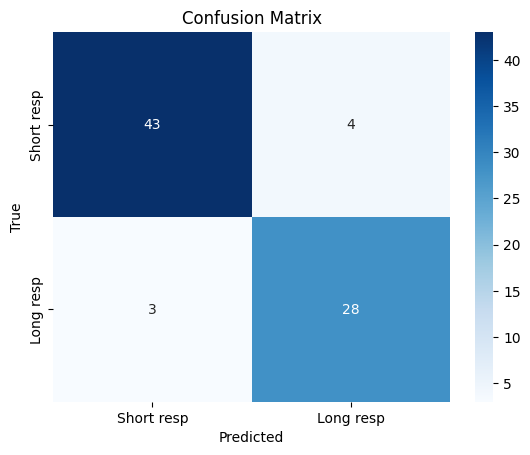

In [15]:
if BINARY_PFS == True:
    results = cross_validate(
        full_pipe, x, y,
        cv=skf,
        scoring=['roc_auc', 'f1'],
        return_train_score=True,
        n_jobs=-1,
        return_estimator=True
    )
    
    print(f"Train ROC-AUC : {results['train_roc_auc'].mean():.3f} ± {results['train_roc_auc'].std():.3f}")
    print(f"Train  F1     : {results['train_f1'].mean():.3f} ± {results['train_f1'].std():.3f}")
    print(f"Test ROC-AUC  : {results['test_roc_auc'].mean():.3f} ± {results['test_roc_auc'].std():.3f}")
    print(f"Test F1       : {results['test_f1'].mean():.3f} ± {results['test_f1'].std():.3f}\n")
    
    target_names = ['Short resp', 'Long resp']
else:
    results = cross_validate(
        full_pipe, x, y,
        cv=skf,
        scoring=['roc_auc_ovo', 'f1_macro'],
        return_train_score=True,
        n_jobs=-1,
        return_estimator=True
    )
    
    print(f"Train ROC-AUC (OVO): {results['train_roc_auc_ovo'].mean():.3f} ± {results['train_roc_auc_ovo'].std():.3f}")
    print(f"Train Macro F1     : {results['train_f1_macro'].mean():.3f} ± {results['train_f1_macro'].std():.3f}")
    print(f"Test ROC-AUC (OVO) : {results['test_roc_auc_ovo'].mean():.3f} ± {results['test_roc_auc_ovo'].std():.3f}")
    print(f"Test Macro F1      : {results['test_f1_macro'].mean():.3f} ± {results['test_f1_macro'].std():.3f}\n")
    
    target_names = ['Short resp', 'Intermediate', 'Long resp']

y_pred = cross_val_predict(
    full_pipe, x, y, 
    cv=skf,
    n_jobs=-1
)

print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## Overlap check

In [16]:
selected_per_fold = []
for tr, _ in skf.split(x, y):
    full_pipe.fit(x.iloc[tr], y.iloc[tr])
    names = full_pipe['preprocess'].get_feature_names_out()
    coefs = full_pipe['clf'].coef_[0]
    mask = coefs != 0
    selected_per_fold.append(set(names[mask]))

gex_per_fold = [{f for f in fold if f.startswith('remainder__')} for fold in selected_per_fold]

common_gex = set.intersection(*gex_per_fold)
union_gex  = set.union(*gex_per_fold)
sizes_gex  = [len(s) for s in gex_per_fold]

print(f"GEX per-fold sizes : {sizes_gex}")
print(f"GEX in all folds   : {len(common_gex)} → {common_gex}")
print(f"GEX union size     : {len(union_gex)}")
print(f"GEX stability ratio: {len(common_gex) / max(1, min(sizes_gex)):.2f}")

GEX per-fold sizes : [20, 20, 20, 20, 20]
GEX in all folds   : 20 → {'remainder__PGM3', 'remainder__SLC25A26', 'remainder__TBC1D1', 'remainder__ADAM9', 'remainder__SLC36A1', 'remainder__STX2', 'remainder__CXCR5', 'remainder__REEP4', 'remainder__LATS2', 'remainder__POU5F1B', 'remainder__CLN8', 'remainder__PYROXD2', 'remainder__PTPDC1', 'remainder__NME7', 'remainder__ALDH5A1', 'remainder__DOCK1', 'remainder__TTYH3', 'remainder__NOTCH1', 'remainder__FANCC', 'remainder__MIR23B'}
GEX union size     : 20
GEX stability ratio: 1.00


In [23]:
with open("../dataset/additional/combine-kegg-vcells.txt") as f:
    kegg_vcells = {g.strip() for g in f.read().split(",")}

GEX_COLS_KEGG = [g for g in common_gex if g in kegg_vcells]

print(f"combine-kegg-vcells genes : {len(kegg_vcells)}")
print(f"GEX_COLS_FILTERED genes   : {len(common_gex)}")
print(f"Overlap (GEX_COLS_KEGG)   : {len(GEX_COLS_KEGG)}")

combine-kegg-vcells genes : 174
GEX_COLS_FILTERED genes   : 20
Overlap (GEX_COLS_KEGG)   : 0


In [17]:
common = set.intersection(*selected_per_fold)
union  = set.union(*selected_per_fold)
sizes = [len(s) for s in selected_per_fold]

print(f"Feature selected per fold : {sizes}")
print(f"Feature in all folds   : {len(common)} → {common}")
print(f"Feature union size     : {len(union)}")
print(f"Feature stability ratio: {len(common) / max(1, min(sizes)):.2f}")

Feature selected per fold : [35, 35, 35, 35, 35]
Feature in all folds   : 35 → {'categorical__sex_female', 'remainder__PGM3', 'drug_braf__MND', 'remainder__SLC25A26', 'remainder__TBC1D1', 'drug_braf__V600E', 'remainder__ADAM9', 'remainder__SLC36A1', 'drug_braf__vemurafenib', 'remainder__STX2', 'remainder__CXCR5', 'remainder__REEP4', 'categorical__AJCC_stage_IV', 'categorical__AJCC_stage_IIIC', 'remainder__LATS2', 'drug_braf__V600K', 'drug_braf__cobimetinib', 'drug_braf__trametinib', 'categorical__LDH_normal', 'remainder__POU5F1B', 'remainder__CLN8', 'remainder__PYROXD2', 'remainder__PTPDC1', 'categorical__sex_male', 'remainder__NME7', 'remainder__ALDH5A1', 'm_stage__M_stage', 'remainder__DOCK1', 'remainder__TTYH3', 'remainder__NOTCH1', 'categorical__LDH_elevated', 'remainder__FANCC', 'remainder__MIR23B', 'drug_braf__dabrafenib', 'age__age'}
Feature union size     : 35
Feature stability ratio: 1.00


## Explainability

In [18]:
print(results['test_roc_auc'])
print(results['test_f1'])

[0.86666667 0.98333333 0.93650794 0.94444444 0.92592593]
[0.83333333 0.92307692 0.85714286 0.90909091 0.92307692]


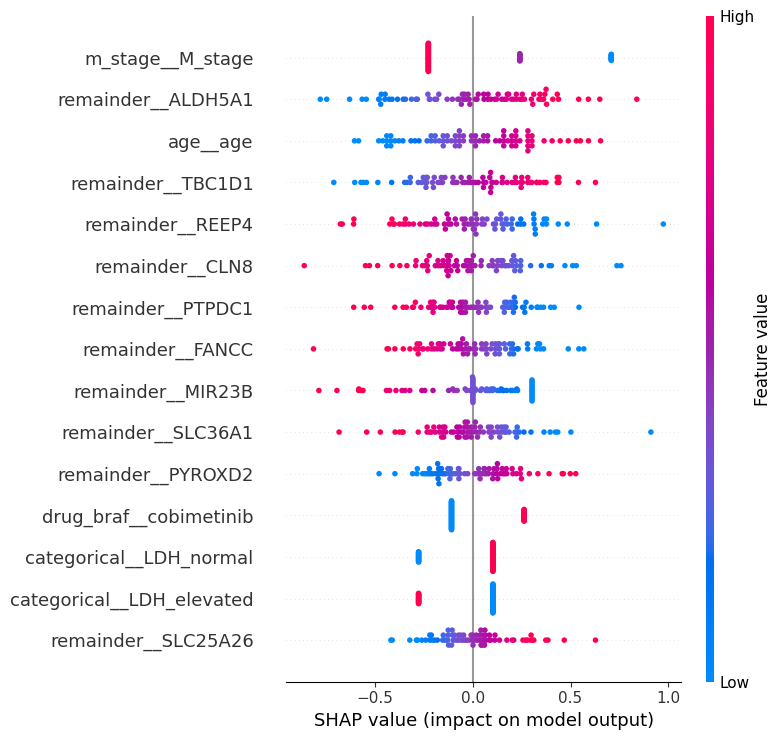

(78, 37)

In [19]:
best_model = results["estimator"][4][-1]

x_transformed = full_pipe[:-1].transform(x)  # x -> prep -> scaler

# Recover feature names after SelectKBest
preprocessed_feature_names = full_pipe['preprocess'].get_feature_names_out()
feature_names = preprocessed_feature_names

explainer = shap.LinearExplainer(best_model, x_transformed)
shap_values = explainer(x_transformed)
shap_values.feature_names = feature_names.tolist()

shap.summary_plot(shap_values, x_transformed, feature_names=feature_names, max_display=15)
x_transformed.shape


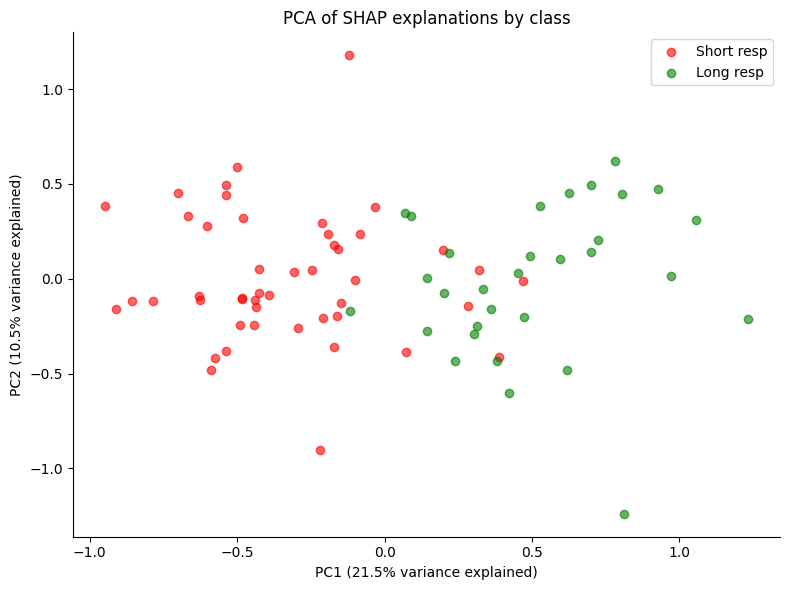

In [20]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap

def plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=None):
    if BINARY_PFS:
        colors = {0: "red", 1: "green"}
        labels = {0: "Short resp", 1: "Long resp"}
    else:
        colors = {0: "red", 1: "orange", 2: "green"}
        labels = {0: "Short resp", 1: "Intermediate", 2: "Long resp"}

    fig, ax = plt.subplots(figsize=(8, 6))

    for cls in sorted(colors):
        mask = y_arr == cls
        ax.scatter(
            sv_2d[mask, 0], sv_2d[mask, 1],
            c=colors[cls], label=labels[cls],
            alpha=0.6,
        )

    if var is not None:
        ax.set_xlabel(f"PC1 ({var[0]:.1%} variance explained)")
        ax.set_ylabel(f"PC2 ({var[1]:.1%} variance explained)")
    else:
        ax.set_xlabel(f"{method_name} 1")
        ax.set_ylabel(f"{method_name} 2")

    ax.set_title(f"{method_name} of SHAP explanations by class")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

y_arr = np.array(y)

# For multiclass SHAP, values are (n_samples, n_features, n_classes) — flatten to 2D
if BINARY_PFS:
    sv_input = shap_values.values                              # already (n_samples, n_features)
else:
    sv_input = shap_values.values.reshape(len(y_arr), -1)     # (n_samples, n_features * n_classes)

# PCA — pass explained variance
pca = PCA(n_components=2)
sv_2d = pca.fit_transform(sv_input)
plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=pca.explained_variance_ratio_)

# # t-SNE
# tsne = TSNE(n_components=2, perplexity=20, random_state=42)
# sv_2d = tsne.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="t-SNE")

# # UMAP
# u_map = umap.UMAP(n_components=2, random_state=42)
# sv_2d = u_map.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="UMAP")

# # PaCMAP
# pac_map = pacmap.PaCMAP(n_components=2, random_state=42)
# sv_2d = pac_map.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="PaCMAP")
